In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Rectangle
import os
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

/home/yipingzou2/anaconda3/envs/mvTCR/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [ ]:
from transformers import (
    AutoModel,
    BertModel,
    BertPreTrainedModel, BertTokenizer
)
from transformers.models.bert.configuration_bert import BertConfig
from typing import Literal, Optional
import logging
import pandas as pd
import numpy as np
import csv
import random
from functools import partial
from sklearn.utils.class_weight import compute_class_weight

def seed_torch(seed=0):
	random.seed(seed)
	os.environ['PYTHONHASHSEED'] = str(seed) # To disable hash randomization for reproducible experiments
	np.random.seed(seed)
	torch.manual_seed(seed)
	torch.cuda.manual_seed(seed)
	torch.cuda.manual_seed_all(seed) # if you are using multi-GPU.
	torch.backends.cudnn.benchmark = False
	torch.backends.cudnn.deterministic = True
	os.environ['CUBLAS_WORKSPACE_CONFIG']=':16:8'
	torch.use_deterministic_algorithms(True)

class FullyConnectedLayer(nn.Module):
    """Single fully connected layer"""

    def __init__(
        self, n_input: int, n_output: int, activation: Optional[nn.Module] = None):
        super().__init__()
        self.n_in = n_input
        self.n_out = n_output
        self.fc = nn.Linear(self.n_in, self.n_out, bias=True)
        nn.init.xavier_uniform_(self.fc.weight)
        self.act = activation

    def forward(self, x) -> torch.Tensor:
        x = self.fc(x)
        if self.act is not None:
            x = self.act(x)
        return x
    
class TwoPartClassLogitsHead(nn.Module):
    """
    Classifier head that takes the encoded representation of TRA and TRB
    of shape (batch, hidden_dim), projects each through its own separate
    fully connected layer, before concatenating and projecting to final
    output
    """

    def __init__(
        self, a_enc_dim: int, b_enc_dim: int, n_out: int = 2, dropout: float = 0.2
    ):
        # BertForSequenceClassification adds, on top of the pooler (dense, tanh),
        # dropout layer with p=0.1
        # classifier linear layer
        super().__init__()
        self.dropout = nn.Dropout(p=dropout, inplace=False)
        self.fc_a = FullyConnectedLayer(a_enc_dim, 256, activation=nn.ReLU())
        self.bn_a = nn.BatchNorm1d(256)
        self.fc_b = FullyConnectedLayer(b_enc_dim, 256, activation=nn.ReLU())
        self.bn_b = nn.BatchNorm1d(256)
        self.fc1 = FullyConnectedLayer(512, 256, activation=nn.ReLU())
        #self.batch_norm_1 = nn.BatchNorm1d(256)
        self.fc2 = FullyConnectedLayer(256, 128, activation=nn.ReLU())
        #self.batch_norm_2 = nn.BatchNorm1d(256)
        #self.final_fc = FullyConnectedLayer(256, 128, activation=nn.ReLU())
        self.last_fc = FullyConnectedLayer(128, n_out, activation=None)

    def forward(self, a_enc, b_enc) -> torch.Tensor:
        a_enc = self.fc_a(self.dropout(a_enc))
        a_enc = self.bn_a(a_enc)
        b_enc = self.fc_b(self.dropout(b_enc))
        b_enc = self.bn_b(b_enc)
        enc = torch.cat([a_enc, b_enc], dim=-1)
        # Apply dropout after the intermediate fully connected layer
        enc = self.fc1(enc)
        #enc = self.batch_norm_1(enc)
        enc = self.dropout(self.fc2(enc))
        #enc = self.batch_norm_2(enc)
        #enc = self.final_fc(enc)
        retval = self.last_fc(enc)
        return retval

class MultiHeadAttentionPooling(nn.Module):
    """Multi-head attention pooling for sequence representation aggregation"""
    def __init__(self, hidden_size, num_heads=8):
        super().__init__()
        self.attention = nn.MultiheadAttention(hidden_size, num_heads, batch_first=True)
        self.query = nn.Parameter(torch.randn(1, 1, hidden_size))
        
    def forward(self, x, attention_mask=None):
        batch_size = x.size(0)
        query = self.query.expand(batch_size, -1, -1)
        
        # Create attention mask
        if attention_mask is not None:
            key_padding_mask = ~attention_mask.to(dtype=torch.bool) 
        # Apply multi-head attention
        pooled_output, _ = self.attention(query, x, x, key_padding_mask=key_padding_mask)
        return pooled_output.squeeze(1)

class FullyConnectedLayer(nn.Module):
    """Single fully connected layer"""

    def __init__(
        self, n_input: int, n_output: int, activation: Optional[nn.Module] = None, 
        use_bn: bool = False, dropout: float = 0.0):
        super().__init__()
        self.n_in = n_input
        self.n_out = n_output
        self.fc = nn.Linear(self.n_in, self.n_out, bias=True)
        nn.init.xavier_uniform_(self.fc.weight)
        self.act = activation
        self.use_bn = use_bn
        self.bn = nn.BatchNorm1d(n_output) if use_bn else None
        self.dropout = nn.Dropout(p=dropout) if dropout > 0 else None

    def forward(self, x) -> torch.Tensor:
        x = self.fc(x)
        if self.bn is not None:
            x = self.bn(x)
        if self.act is not None:
            x = self.act(x)
        if self.dropout is not None:
            x = self.dropout(x)
        return x
        
class ResidualBlock(nn.Module):
    """Residual connection module"""
    def __init__(self, hidden_size, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(hidden_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.act = nn.ReLU()
        
    def forward(self, x):
        residual = x
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = x + residual  # Residual connection
        x = self.act(x)
        return x

class ImprovedTwoPartClassHead(nn.Module):
    """
    Improved classifier head combining residual connections, self-attention and feature fusion
    """
    def __init__(
        self, a_enc_dim: int, b_enc_dim: int, n_out: int = 1, 
        hidden_dim: int = 256, dropout: float = 0.2
    ):
        super().__init__()
        
        # Alpha chain feature extraction
        self.fc_a1 = FullyConnectedLayer(a_enc_dim, hidden_dim, activation=nn.ReLU(), use_bn=True, dropout=dropout)
        self.res_a = ResidualBlock(hidden_dim, dropout=dropout)
        
        # Beta chain feature extraction
        self.fc_b1 = FullyConnectedLayer(b_enc_dim, hidden_dim, activation=nn.ReLU(), use_bn=True, dropout=dropout)
        self.res_b = ResidualBlock(hidden_dim, dropout=dropout)
        
        # Cross attention fusion
        self.cross_attn = nn.MultiheadAttention(hidden_dim, num_heads=4, batch_first=True)
        
        # Feature fusion
        self.fusion = nn.Sequential(
            FullyConnectedLayer(hidden_dim * 2, hidden_dim, activation=nn.ReLU(), use_bn=True, dropout=dropout),
            ResidualBlock(hidden_dim, dropout=dropout),
            FullyConnectedLayer(hidden_dim, hidden_dim // 2, activation=nn.ReLU(), use_bn=True, dropout=dropout)
        )
        
        # Classification layer
        self.classifier = nn.Linear(hidden_dim // 2, n_out)
        
        # Feature gating mechanism
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim * 2),
            nn.Sigmoid()
        )
        
        # Initialize classifier weights
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.constant_(self.classifier.bias, 0)
        
    def forward(self, a_enc, b_enc) -> torch.Tensor:
        # Process Alpha chain
        a_feat = self.fc_a1(a_enc)
        a_feat = self.res_a(a_feat)
        
        # Process Beta chain
        b_feat = self.fc_b1(b_enc)
        b_feat = self.res_b(b_feat)
        
        # Cross attention fusion (sequence of batch size 1)
        a_feat_expanded = a_feat.unsqueeze(1)  # [batch, 1, hidden_dim]
        b_feat_expanded = b_feat.unsqueeze(1)  # [batch, 1, hidden_dim]
        
        # Alpha attends to Beta
        a_attends_b, _ = self.cross_attn(a_feat_expanded, b_feat_expanded, b_feat_expanded)
        a_attends_b = a_attends_b.squeeze(1)  # [batch, hidden_dim]
        
        # Beta attends to Alpha
        b_attends_a, _ = self.cross_attn(b_feat_expanded, a_feat_expanded, a_feat_expanded)
        b_attends_a = b_attends_a.squeeze(1)  # [batch, hidden_dim]
        
        # Feature fusion
        combined = torch.cat([a_attends_b, b_attends_a], dim=-1)
        
        # Apply feature gating
        gate_values = self.gate(combined)
        gated_features = combined * gate_values
        
        # Final feature processing
        fused = self.fusion(gated_features)
        
        # Classification
        logits = self.classifier(fused)
        
        return logits

    
class TwoPartBertClassifier(nn.Module):
    """
    Two part BERT model, one part each for tcr a/b with gradual unfreezing capability
    """

    def __init__(
        self,
        pretrained: str,
        n_output: int = 2,
        freeze_encoder: bool = True,  # Default freeze encoder
        separate_encoders: bool = True,
        dropout: float = 0.2,
        seq_pooling: Literal["max", "mean", "cls", "pool", "attention"] = "cls",
    ):
        super().__init__()
        self.pooling_strat = seq_pooling
        self.pretrained = pretrained
        
        self.trans_a = self.__initialize_transformer()
        if separate_encoders:
            self.trans_b = self.__initialize_transformer()
        else:
            self.trans_b = self.trans_a
        self.bert_variant = self.trans_a.base_model_prefix

        if self.trans_a != self.trans_b:
            print("Seperate encoders!")
            
        hidden_size = self.trans_a.encoder.layer[-1].output.dense.out_features
         # Initialize attention pooling layer (if needed)
        if seq_pooling == "attention":
            self.attention_pool_a = MultiHeadAttentionPooling(hidden_size)
            self.attention_pool_b = MultiHeadAttentionPooling(hidden_size)
        
        # Initially freeze all BERT layers
        if freeze_encoder:
            self._freeze_all_encoder_layers()

        self.head = ImprovedTwoPartClassHead(
            self.trans_a.encoder.layer[-1].output.dense.out_features,
            self.trans_b.encoder.layer[-1].output.dense.out_features,
            n_out=n_output,
            dropout=dropout,
        )
        
        # Track number of unfrozen layers
        self.unfrozen_layers = 0

    def __initialize_transformer(self) -> BertModel:
        """
        Centralized helper function to initialize transformer for
        encoding input sequences
        """
        if os.path.isdir(self.pretrained):
            logging.info(
                "Got json config as 'pretrained' - initializing BERT model from scratch"
            )
            config = BertConfig.from_pretrained(self.pretrained)
            retval = BertModel.from_pretrained(self.pretrained, config=config)
        else:
            retval = AutoModel.from_pretrained(
                self.pretrained, add_pooling_layer=self.pooling_strat == "pool"
            )
        return retval
    
    def _freeze_all_encoder_layers(self):
        """Freeze all BERT encoder layers"""
        for param in self.trans_a.parameters():
            param.requires_grad = False
        
        if self.trans_a != self.trans_b:  # Only needed when using separate encoders
            for param in self.trans_b.parameters():
                param.requires_grad = False
    
    def unfreeze_next_layer(self):
        """Unfreeze next BERT layer, starting from the last layer"""
        if self.unfrozen_layers >= len(self.trans_a.encoder.layer):
            print("All layers are already unfrozen")
            return False
        
        # Calculate layer index to unfreeze (starting from the last layer)
        layer_to_unfreeze = len(self.trans_a.encoder.layer) - 1 - self.unfrozen_layers
        
        # Unfreeze trans_a layer
        for name, param in self.trans_a.encoder.layer[layer_to_unfreeze].named_parameters():
            param.requires_grad = True
        
        # If using separate encoders, also unfreeze trans_b layer
        if self.trans_a != self.trans_b:
            for name, param in self.trans_b.encoder.layer[layer_to_unfreeze].named_parameters():
                param.requires_grad = True
        
        self.unfrozen_layers += 1
        print(f"Unfroze BERT layer {layer_to_unfreeze}, currently {self.unfrozen_layers} layers unfrozen")
        return True
    
    def unfreeze_embeddings(self):
        """Unfreeze embedding layer"""
        for param in self.trans_a.embeddings.parameters():
            param.requires_grad = True
            
        if self.trans_a != self.trans_b:
            for param in self.trans_b.embeddings.parameters():
                param.requires_grad = True
        
        print("Embedding layer unfrozen")
        return True

    def forward(self, tcr_a, tcr_b):
        if self.bert_variant == "bert":
            a_enc = self.trans_a(**tcr_a)
            b_enc = self.trans_b(**tcr_b)
        else:
            a_enc = self.trans_a(**tcr_a)[0]
            b_enc = self.trans_b(**tcr_b)[0]
            raise NotImplementedError

        # Perform seq pooling
        if self.pooling_strat == "mean":
            a_attention_mask = tcr_a.get('attention_mask', None)
            b_attention_mask = tcr_b.get('attention_mask', None)
            a_enc = mean_pooling(a_enc.last_hidden_state, a_attention_mask) #a_enc.last_hidden_state.mean(dim=1)
            b_enc = mean_pooling(b_enc.last_hidden_state, b_attention_mask) #b_enc.last_hidden_state.mean(dim=1)
        elif self.pooling_strat == "max":
            a_enc = a_enc.last_hidden_state.max(dim=1)[0]
            b_enc = b_enc.last_hidden_state.max(dim=1)[0]
        elif self.pooling_strat == "cls":
            a_enc = a_enc.last_hidden_state[:, 0, :]
            b_enc = b_enc.last_hidden_state[:, 0, :]
        elif self.pooling_strat == "pool":
            a_enc = a_enc.pooler_output
            b_enc = b_enc.pooler_output
        elif self.pooling_strat == "attention":
            a_attention_mask = tcr_a.get('attention_mask', None)
            b_attention_mask = tcr_b.get('attention_mask', None)
            a_enc = self.attention_pool_a(a_enc.last_hidden_state, attention_mask=a_attention_mask)
            b_enc = self.attention_pool_b(b_enc.last_hidden_state, attention_mask=b_attention_mask)
        else:
            raise ValueError(f"Unrecognized pooling strategy: {self.pooling_strat}")
    
        retval = self.head(a_enc, b_enc)
        return retval

def mean_pooling(sequence_output, attention_mask=None):
  """
  Implement mean pooling considering attention mask
  """
  if attention_mask is not None:
      # Expand mask dimensions to match sequence output
      attention_mask = attention_mask.unsqueeze(-1)
      
      # Apply mask and calculate mean
      # Only consider valid tokens (mask=1)
      sum_embeddings = torch.sum(sequence_output * attention_mask, dim=1)
      sum_mask = torch.sum(attention_mask, dim=1)
      
      # Avoid division by zero
      sum_mask = torch.clamp(sum_mask, min=1e-9)
      
      # Calculate mean
      mean_embeddings = sum_embeddings / sum_mask
      return mean_embeddings
  else:
      # If no mask, simply calculate mean
      return torch.mean(sequence_output, dim=1)


/home/yipingzou2/anaconda3/envs/mvTCR/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class TCRAttentionExtractor:
    def __init__(self):
        self.attention_weights = {}
        self.hooks = []
        self.extracting = False  # Flag to prevent recursion
    
    def get_attention_hook(self, name):
        def hook(module, input, output):
            # Prevent recursion
            if self.extracting:
                return
                
            if isinstance(module, nn.MultiheadAttention):
                # Extract attention weights from the output
                # MultiheadAttention returns (attn_output, attn_output_weights) when need_weights=True
                if isinstance(output, tuple) and len(output) == 2:
                    attn_output, attn_weights = output
                    if attn_weights is not None:
                        self.attention_weights[name] = attn_weights.detach().cpu()
        return hook
    
    def register_hooks(self, model):
        if hasattr(model, 'attention_pool_a'):
            hook_a = self.get_attention_hook('alpha_attention')
            handle_a = model.attention_pool_a.attention.register_forward_hook(hook_a)
            self.hooks.append(handle_a)
            
        if hasattr(model, 'attention_pool_b'):
            hook_b = self.get_attention_hook('beta_attention')
            handle_b = model.attention_pool_b.attention.register_forward_hook(hook_b)
            self.hooks.append(handle_b)
    
    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()
        self.hooks = []

def extract_tcr_attention(model, tcr_a_tokens, tcr_b_tokens, device):
    """Extract attention weights for TCR sequences"""
    model.eval()
    
    extractor = TCRAttentionExtractor()
    extractor.register_hooks(model)
    
    # Move data to device
    tcr_a = {key: val.to(device) for key, val in tcr_a_tokens.items()}
    tcr_b = {key: val.to(device) for key, val in tcr_b_tokens.items()}
    
    with torch.no_grad():
        predictions = model(tcr_a, tcr_b)
    
    alpha_attention = extractor.attention_weights.get('alpha_attention')
    beta_attention = extractor.attention_weights.get('beta_attention')
    
    extractor.remove_hooks()
    
    return alpha_attention, beta_attention, predictions

def tokens_to_amino_acids(tokens, tokenizer):
    """Convert token IDs to amino acid sequences"""
    if isinstance(tokens, torch.Tensor):
        tokens = tokens.squeeze().tolist()
    
    # Convert to tokens
    token_strings = tokenizer.convert_ids_to_tokens(tokens)
    
    # Remove special tokens and whitespace
    amino_acids = []
    for token in token_strings:
        if token not in ['[CLS]', '[SEP]', '[PAD]', '[UNK]']:
            # Remove whitespace (your model uses insert_whitespace)
            clean_token = token.replace('▁', '').replace(' ', '')
            if clean_token:
                amino_acids.append(clean_token)
    
    return amino_acids



def extract_tcr_attention_from_model(model, tokenizer, tcr_alpha_sequence, tcr_beta_sequence, 
                                      device, class_names=None, max_len=30):
    """
    Complete pipeline to visualize TCR attention from your trained model
    
    Args:
        model: Your trained TwoPartBertClassifier model
        tokenizer: Your BertTokenizer
        tcr_alpha_sequence: Alpha chain amino acid sequence (string)
        tcr_beta_sequence: Beta chain amino acid sequence (string)
        device: torch device
        class_names: List of class names for visualization
        max_len: Maximum sequence length for tokenization
        save_plots: Whether to save plots
        output_dir: Directory to save plots
    """
    
    if class_names is None:
        class_names = ['HLA-A*02:01', 'HLA-A*03:01', 'Others']  # Adjust based on your classes
    
    # Process sequences (add whitespace as your model expects)
    tcr_alpha_processed = insert_whitespace(tcr_alpha_sequence)
    tcr_beta_processed = insert_whitespace(tcr_beta_sequence)
    
    # Tokenize sequences
    tcr_a_tokens = tokenizer(tcr_alpha_processed, truncation=True, 
                            padding='max_length', max_length=max_len, 
                            return_tensors='pt')
    tcr_b_tokens = tokenizer(tcr_beta_processed, truncation=True, 
                            padding='max_length', max_length=max_len, 
                            return_tensors='pt')
    
    # Extract attention weights
    alpha_attention, beta_attention, predictions = extract_tcr_attention(
        model, tcr_a_tokens, tcr_b_tokens, device)
    
    if alpha_attention is None or beta_attention is None:
        print("Failed to extract attention weights!")
        return None
    
    # Convert tokens to amino acids
    alpha_amino_acids = tokens_to_amino_acids(tcr_a_tokens['input_ids'], tokenizer)
    beta_amino_acids = tokens_to_amino_acids(tcr_b_tokens['input_ids'], tokenizer)
    
    # Get prediction probabilities
    prediction_probs = torch.softmax(predictions, dim=-1)
    predicted_class = torch.argmax(prediction_probs, dim=-1).item()
    
    #print(f"\nModel Prediction: {class_names[predicted_class]} (confidence: {prediction_probs[0][predicted_class]:.4f})")
    
    return {
        'alpha_attention': alpha_attention,
        'beta_attention': beta_attention,
        'alpha_amino_acids': alpha_amino_acids,
        'beta_amino_acids': beta_amino_acids,
        'prediction': predictions.detach().cpu().numpy(),
        'prediction_probs': prediction_probs.detach().cpu().numpy(),
        'predicted_class': predicted_class
    }
  

def is_whitespaced(seq: str) -> bool:
    """
    Return whether the sequence has whitespace inserted
    >>> is_whitespaced("R K D E S")
    True
    >>> is_whitespaced("RKDES")
    False
    >>> is_whitespaced("R K D ES")
    False
    >>> is_whitespaced("R")
    True
    >>> is_whitespaced("RK")
    False
    >>> is_whitespaced("R K")
    True
    """
    tok = list(seq)
    spaces = [t for t in tok if t.isspace()]
    if len(spaces) == np.floor(len(seq) / 2):
        return True
    return False

def insert_whitespace(seq: str) -> str:
    """
    Return the sequence of characters with whitespace after each char
    >>> insert_whitespace("RKDES")
    'R K D E S'
    """
    return " ".join(list(seq))


In [4]:
from libtcrlm import schema
import tidytcells as tt

def complete_full_tcr(df: pd.DataFrame):
    dataframe = df.rename(columns={'v.alpha':'TRAV', 'cdr3.alpha':'CDR3A','v.beta':'TRBV', 'cdr3.beta':'CDR3B'})
    dataframe = dataframe[['TRAV', 'CDR3A', 'TRBV', 'CDR3B']]
    for col in ("TRAV", "TRBV"):
        dataframe[col] = dataframe[col].map(tt.tr.standardize)
    for col in ('CDR3A', 'CDR3B'):
        dataframe[col] = dataframe[col].map(tt.junction.standardize)
    tcrs = schema.generate_tcr_series(dataframe)
    completed_tcrA = []
    completed_tcrB = []
    cdr1a = []
    cdr1b = []
    cdr2a = []
    cdr2b = []
    for tcr in tcrs:
        completed_tcrA.append(tcr.cdr1a_sequence + tcr.cdr2a_sequence + tcr.junction_a_sequence)
        completed_tcrB.append(tcr.cdr1b_sequence + tcr.cdr2b_sequence + tcr.junction_b_sequence)
        cdr1a.append(tcr.cdr1a_sequence)
        cdr1b.append(tcr.cdr1b_sequence)
        cdr2a.append(tcr.cdr2a_sequence)
        cdr2b.append(tcr.cdr2b_sequence)
    assert(len(completed_tcrA) == len(completed_tcrB) == len(df))
    df['full.alpha'] = completed_tcrA
    df['full.beta'] = completed_tcrB
    df['cdr1a'] = cdr1a
    df['cdr1b'] = cdr1b
    df['cdr2a'] = cdr2a
    df['cdr2b'] = cdr2b
    
    return df

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def map_positions_to_cdr_regions(full_sequence, cdr1, cdr2, cdr3):
    """
    Map positions in the full sequence to CDR regions
    
    Args:
        full_sequence: Complete sequence (e.g., full.alpha or full.beta)
        cdr1, cdr2, cdr3: Individual CDR sequences
    
    Returns:
        Dictionary mapping position to region name
    """
    position_to_region = {}
    
    # Find positions of each CDR in the full sequence
    cdr1_start = full_sequence.find(cdr1)
    cdr2_start = full_sequence.find(cdr2)
    cdr3_start = full_sequence.find(cdr3)
    
    # Mark CDR1 positions
    if cdr1_start != -1:
        for i in range(cdr1_start, cdr1_start + len(cdr1)):
            position_to_region[i] = 'CDR1'
    
    # Mark CDR2 positions
    if cdr2_start != -1:
        for i in range(cdr2_start, cdr2_start + len(cdr2)):
            position_to_region[i] = 'CDR2'
    
    # Mark CDR3 positions
    if cdr3_start != -1:
        for i in range(cdr3_start, cdr3_start + len(cdr3)):
            position_to_region[i] = 'CDR3'
    
    # Mark remaining positions as Framework
    for i in range(len(full_sequence)):
        if i not in position_to_region:
            position_to_region[i] = 'Framework'
    
    return position_to_region

def get_amino_acid_to_cdr_mapping(amino_acids, position_to_region):
    """
    Map amino acid tokens to CDR regions, handling tokenization artifacts
    
    Args:
        amino_acids: List of amino acid tokens from tokenizer
        position_to_region: Dictionary mapping sequence positions to CDR regions
    
    Returns:
        List of region names for each amino acid token
    """
    regions = []
    sequence_position = 0
    
    for token in amino_acids:
        if token in ['*', '|', '$']:
            regions.append('Special')
        else:
            # Map current sequence position to region
            if sequence_position in position_to_region:
                regions.append(position_to_region[sequence_position])
            else:
                regions.append('Framework')
            sequence_position += 1
    
    return regions

def process_chain_data(results, tcr_data, chain_type):
    """Process data for a single chain"""
    if chain_type == 'alpha':
        attention_weights = results['alpha_attention'].reshape(-1)
        amino_acids = results['alpha_amino_acids']
        full_sequence = tcr_data['full.alpha']
        cdr1, cdr2, cdr3 = tcr_data['cdr1a'], tcr_data['cdr2a'], tcr_data['cdr3.alpha']
    else:
        attention_weights = results['beta_attention'].reshape(-1)
        amino_acids = results['beta_amino_acids']
        full_sequence = tcr_data['full.beta']
        cdr1, cdr2, cdr3 = tcr_data['cdr1b'], tcr_data['cdr2b'], tcr_data['cdr3.beta']
    
    # Remove special tokens from attention and amino acids
    filtered_attention = []
    filtered_amino_acids = []
    
    for i, aa in enumerate(amino_acids):
        if aa not in ['*', '|', '$']:
            filtered_attention.append(attention_weights[i])
            filtered_amino_acids.append(aa)
    
    attention_weights = np.array(filtered_attention)
    amino_acids = filtered_amino_acids
    
    # Map positions to CDR regions
    position_to_region = map_positions_to_cdr_regions(full_sequence, cdr1, cdr2, cdr3)
    regions = get_amino_acid_to_cdr_mapping(amino_acids, position_to_region)
    
    return attention_weights, amino_acids, regions

def plot_tcr_attention_both_chains(results, tcr_data, figsize=(15, 8), save_path=None):
    """
    Plot TCR attention weights for both alpha and beta chains with CDR regions highlighted
    
    Args:
        results: Results from extract_tcr_attention_from_model
        tcr_data: Dictionary containing CDR sequences
        figsize: Figure size
        save_path: Path to save the plot
    """
    
    # Process both chains
    alpha_attention, alpha_amino_acids, alpha_regions = process_chain_data(results, tcr_data, 'alpha')
    beta_attention, beta_amino_acids, beta_regions = process_chain_data(results, tcr_data, 'beta')
    
    # Define colors for each region
    region_colors = {
        'CDR1': '#69A3DD',      # Red
        'CDR2': '#4ECDC4',      # Teal
        'CDR3': "#CA4444",      # Blue
        'Framework': '#96CEB4',  # Light green
        'Special': '#FFEAA7'     # Light yellow
    }
    
    # Convert regions to numeric values for imshow
    region_numeric_map = {
        'CDR1': 1,
        'CDR2': 2,
        'CDR3': 3,
        'Framework': 0,
        'Special': 4
    }
    
    alpha_region_numeric = [region_numeric_map.get(region, 0) for region in alpha_regions]
    beta_region_numeric = [region_numeric_map.get(region, 0) for region in beta_regions]
    
    # Create custom colormap
    from matplotlib.colors import ListedColormap
    colors = ['#96CEB4', '#69A3DD', '#4ECDC4', '#CA4444', '#FFEAA7']  # Framework, CDR1, CDR2, CDR3, Special
    custom_cmap = ListedColormap(colors)
    
    # Create the plot with 4 subplots (2 for regions, 2 for attention)
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=figsize, 
                                                 gridspec_kw={'height_ratios': [1, 4]})
    
    # Alpha chain - Region color bar
    ax1.imshow([alpha_region_numeric], aspect='auto', extent=[0, len(alpha_amino_acids), 0, 1],
               cmap=custom_cmap, vmin=0, vmax=4)
    ax1.set_xlim(0, len(alpha_amino_acids))
    ax1.set_yticks([])
    ax1.set_title('TCR Alpha Chain - CDR Regions', fontsize=14, fontweight='bold')
    
    # Add region labels for alpha
    add_region_labels(ax1, alpha_regions)
    
    # Beta chain - Region color bar
    ax2.imshow([beta_region_numeric], aspect='auto', extent=[0, len(beta_amino_acids), 0, 1],
               cmap=custom_cmap, vmin=0, vmax=4)
    ax2.set_xlim(0, len(beta_amino_acids))
    ax2.set_yticks([])
    ax2.set_title('TCR Beta Chain - CDR Regions', fontsize=14, fontweight='bold')
    
    # Add region labels for beta
    add_region_labels(ax2, beta_regions)
    
    # Alpha chain - Attention heatmap
    alpha_attention_matrix = alpha_attention.reshape(1, -1)
    im1 = ax3.imshow(alpha_attention_matrix, cmap='Reds', aspect=8, 
                     extent=[0, len(alpha_amino_acids), 0, 1])
    
    # Set amino acid labels for alpha
    ax3.set_xticks(range(len(alpha_amino_acids)))
    ax3.set_xticklabels(alpha_amino_acids, rotation=45, ha='right')
    ax3.set_yticks([])
    ax3.set_xlabel('Amino Acid Position', fontsize=12)
    ax3.set_title('Alpha Chain Attention Weights', fontsize=12)
    
    # Color the amino acid labels by region for alpha
    for i, (label, region) in enumerate(zip(ax3.get_xticklabels(), alpha_regions)):
        if region in region_colors:
            label.set_color(region_colors[region])
            label.set_fontweight('bold')
    
    # Beta chain - Attention heatmap
    beta_attention_matrix = beta_attention.reshape(1, -1)
    im2 = ax4.imshow(beta_attention_matrix, cmap='Reds', aspect=8, 
                     extent=[0, len(beta_amino_acids), 0, 1])
    
    # Set amino acid labels for beta
    ax4.set_xticks(range(len(beta_amino_acids)))
    ax4.set_xticklabels(beta_amino_acids, rotation=45, ha='right')
    ax4.set_yticks([])
    ax4.set_xlabel('Amino Acid Position', fontsize=12)
    ax4.set_title('Beta Chain Attention Weights', fontsize=12)
    
    # Color the amino acid labels by region for beta
    for i, (label, region) in enumerate(zip(ax4.get_xticklabels(), beta_regions)):
        if region in region_colors:
            label.set_color(region_colors[region])
            label.set_fontweight('bold')
    
    # Add colorbars
    cbar1 = plt.colorbar(im1, ax=ax3, orientation='horizontal', pad=0.15, shrink=0.6, aspect=10)
    cbar1.set_label('Alpha Chain Attention Weight', fontsize=10)
    
    cbar2 = plt.colorbar(im2, ax=ax4, orientation='horizontal', pad=0.15, shrink=0.6, aspect=10)
    cbar2.set_label('Beta Chain Attention Weight', fontsize=10)
    
    # Add legend (only once)
    unique_regions = list(set(alpha_regions + beta_regions))
    if 'Special' in unique_regions:
        unique_regions.remove('Special')  # Don't show special tokens in legend
    
    legend_elements = [plt.Rectangle((0,0),1,1, facecolor=region_colors[region], label=region) 
                      for region in unique_regions if region in region_colors]
    ax4.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 1))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, transparent=True, bbox_inches='tight')
    
    plt.show()
    
def add_region_labels(ax, regions):
    """Add region labels to the color bar"""
    current_region = None
    region_start = 0
    for i, region in enumerate(regions):
        if region != current_region:
            if current_region is not None and current_region != 'Special':
                # Add label for previous region
                region_center = (region_start + i) / 2
                ax.text(region_center, 0.5, current_region, 
                       ha='center', va='center', fontweight='bold', fontsize=10)
            current_region = region
            region_start = i
    
    # Add label for last region
    if current_region is not None and current_region != 'Special':
        region_center = (region_start + len(regions)) / 2
        ax.text(region_center, 0.5, current_region, 
               ha='center', va='center', fontweight='bold', fontsize=10)

def print_attention_statistics_by_region(attention_weights, regions, amino_acids):
    """Print attention statistics grouped by CDR regions"""
    
    region_stats = {}
    for i, (weight, region, aa) in enumerate(zip(attention_weights, regions, amino_acids)):
        if region not in region_stats:
            region_stats[region] = {'weights': [], 'positions': [], 'amino_acids': []}
        region_stats[region]['weights'].append(weight)
        region_stats[region]['positions'].append(i)
        region_stats[region]['amino_acids'].append(aa)
    
    for region, stats in region_stats.items():
        if region == 'Special':
            continue
            
        weights = np.array(stats['weights'])
        print(f"\n{region}:")
        print(f"  Positions: {stats['positions']}")
        print(f"  Amino acids: {' '.join(stats['amino_acids'])}")
        print(f"  Mean attention: {weights.mean():.4f}")
        print(f"  Max attention: {weights.max():.4f}")
        print(f"  Total attention: {weights.sum():.4f}")
        print(f"  Attention proportion: {weights.sum()/attention_weights.sum():.2%}")


Some weights of BertModel were not initialized from the model checkpoint at /mnt/d/TCRpair/bert and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertModel were not initialized from the model checkpoint at /mnt/d/TCRpair/bert and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Seperate encoders!


/tmp/ipykernel_1393605/3171084871.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['full.alpha'] = completed_tcrA
/tmp/ipykernel_1393605/3171084871.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['full.beta'] = completed_tcrB
/tmp/ipykernel_1393605/3171084871.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stabl

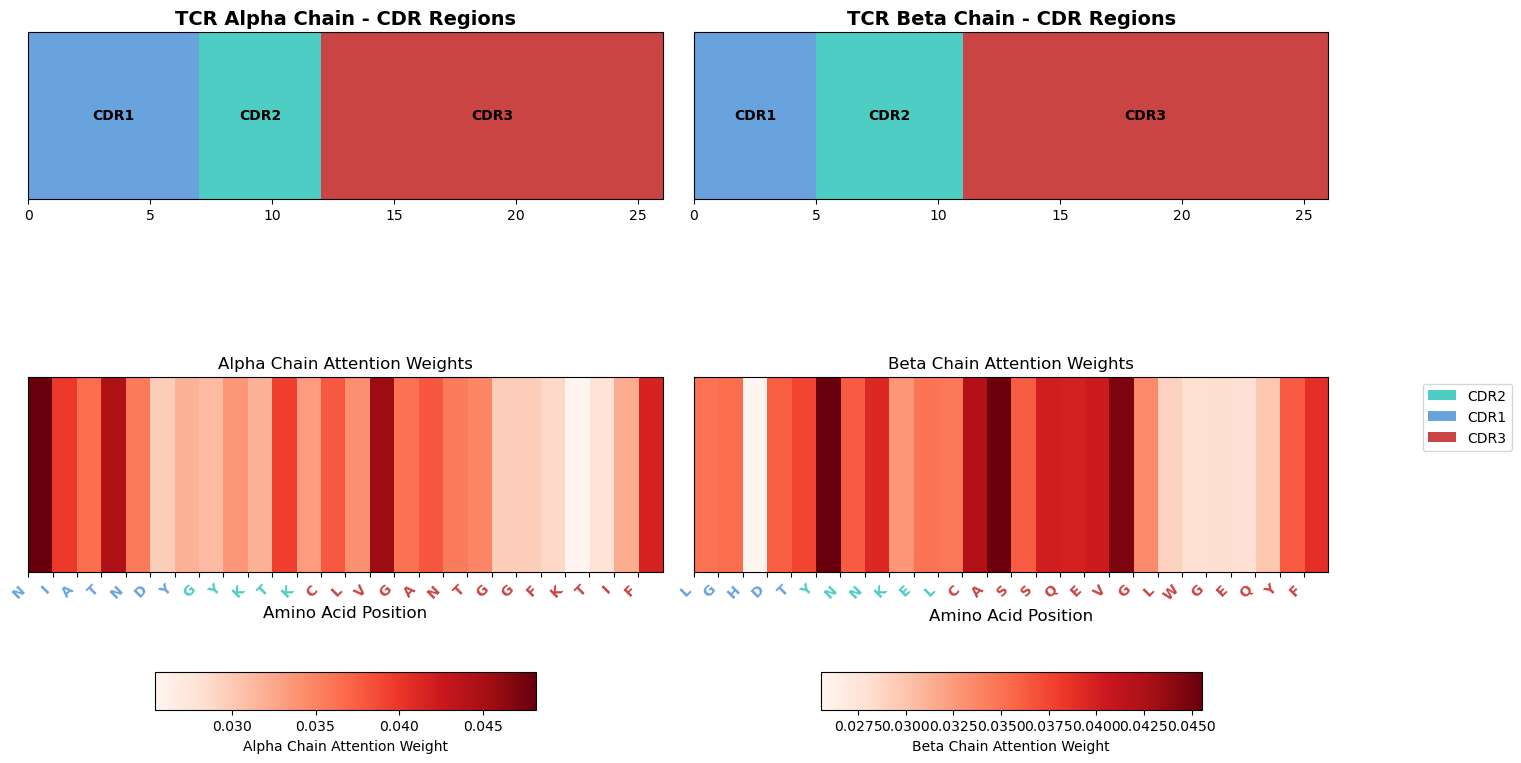

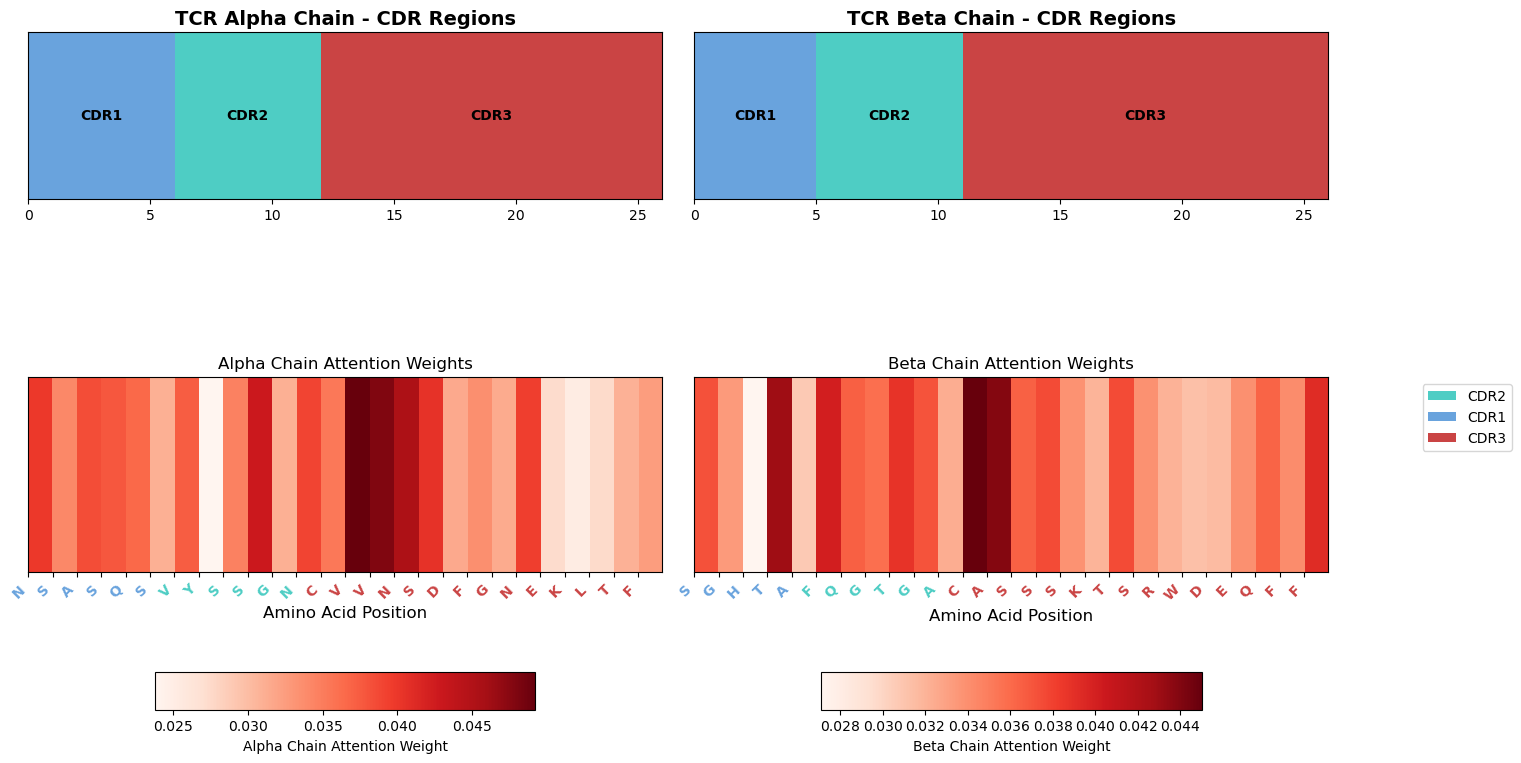

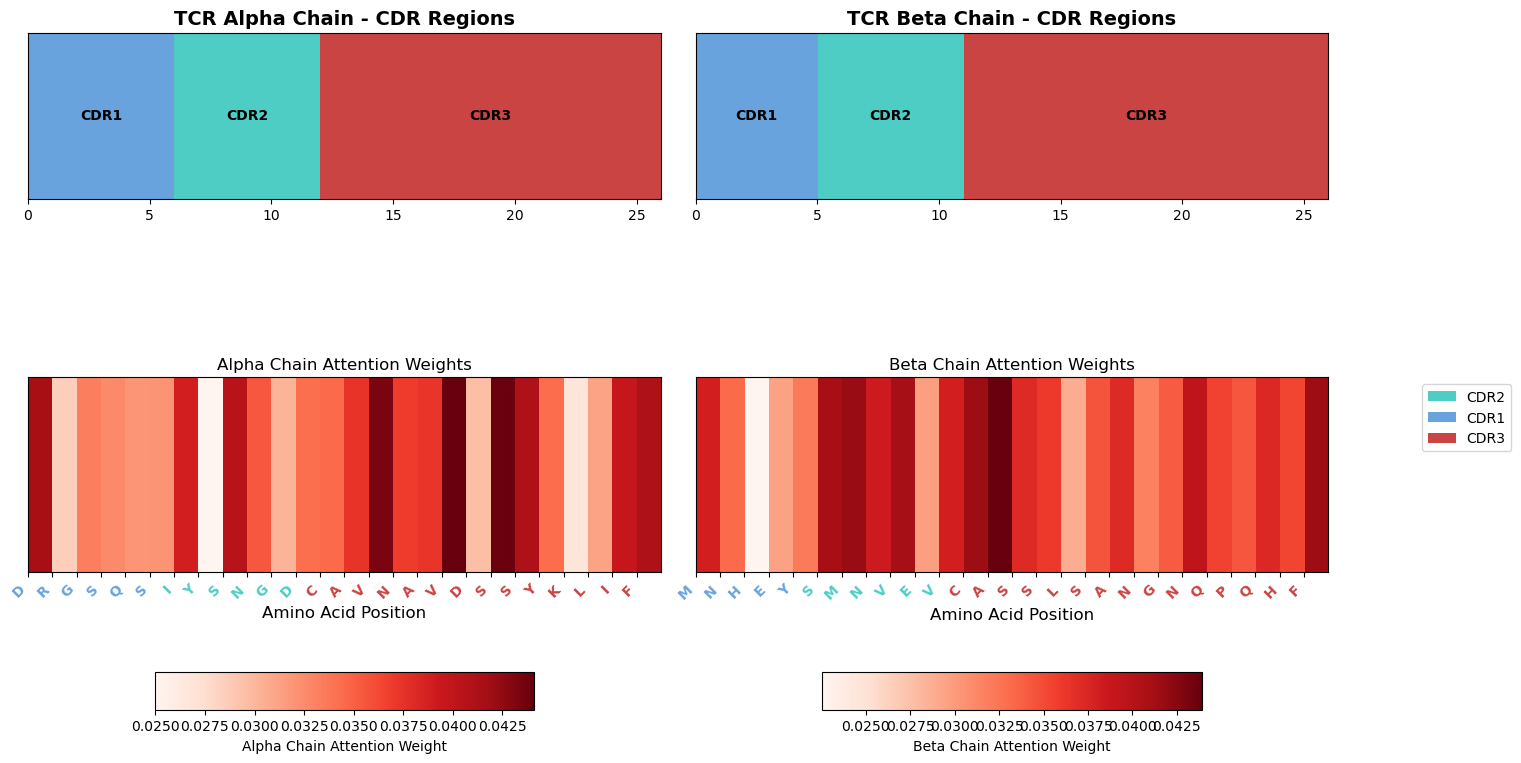

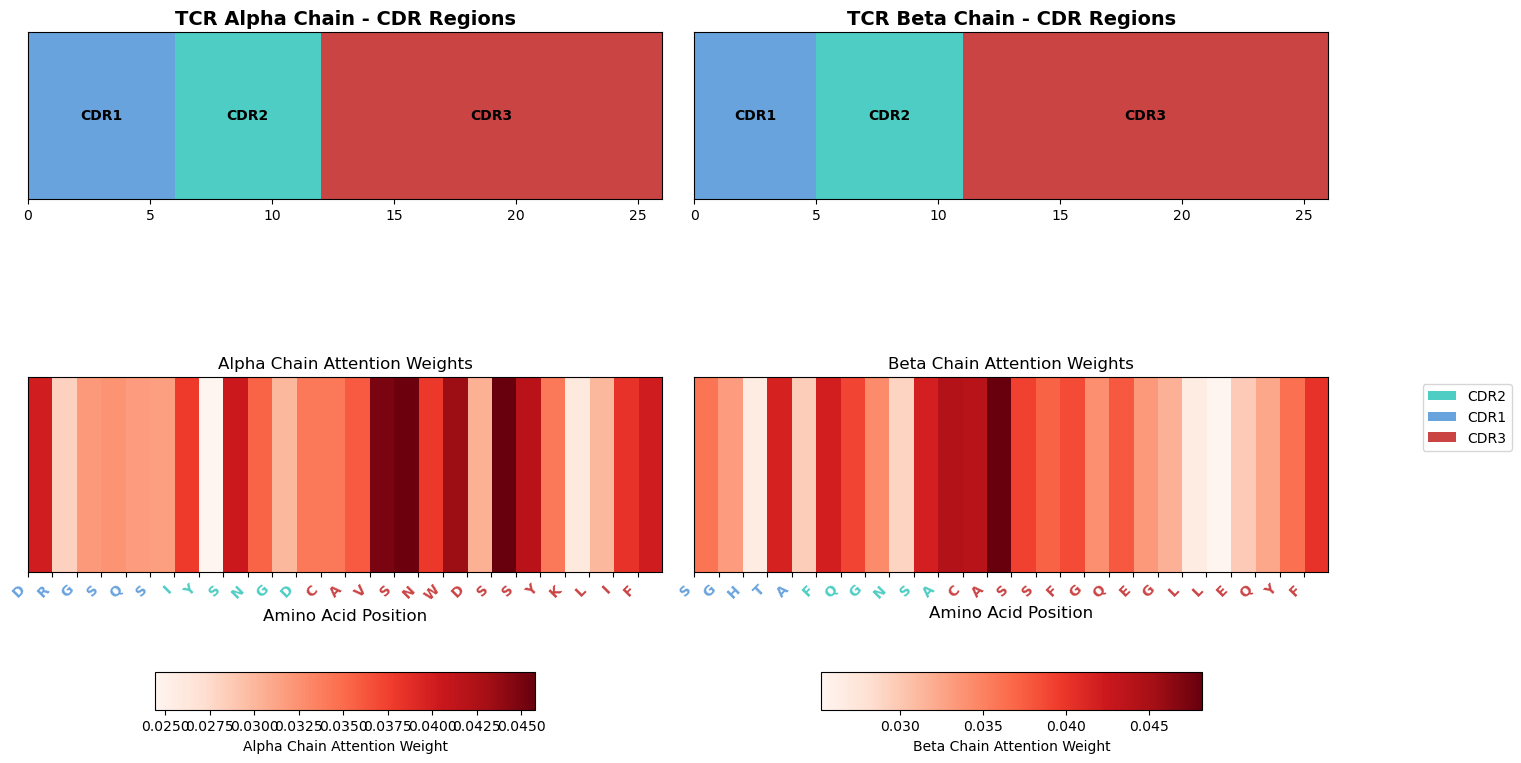

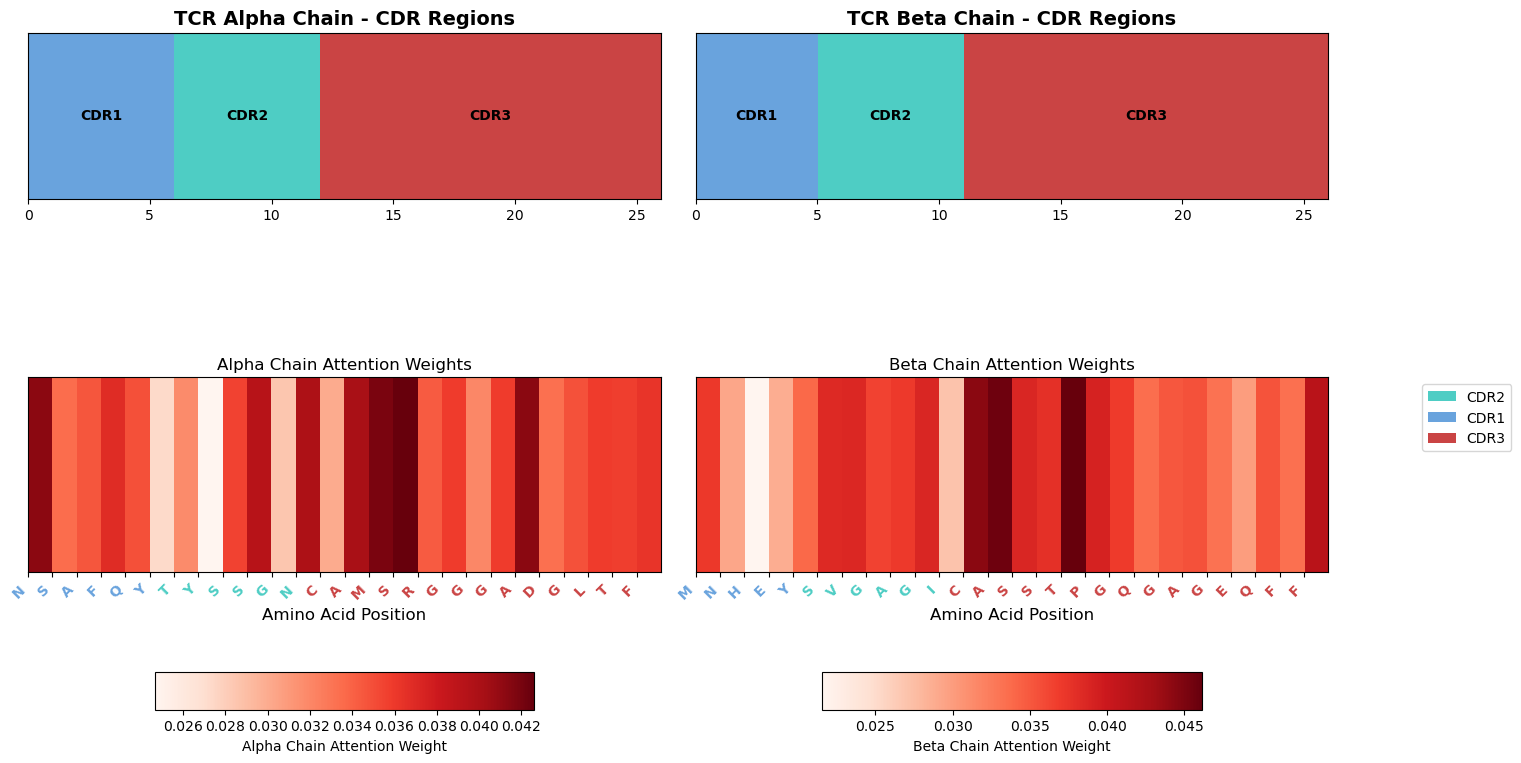

/tmp/ipykernel_1393605/3171084871.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['full.alpha'] = completed_tcrA
/tmp/ipykernel_1393605/3171084871.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['full.beta'] = completed_tcrB
/tmp/ipykernel_1393605/3171084871.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stabl

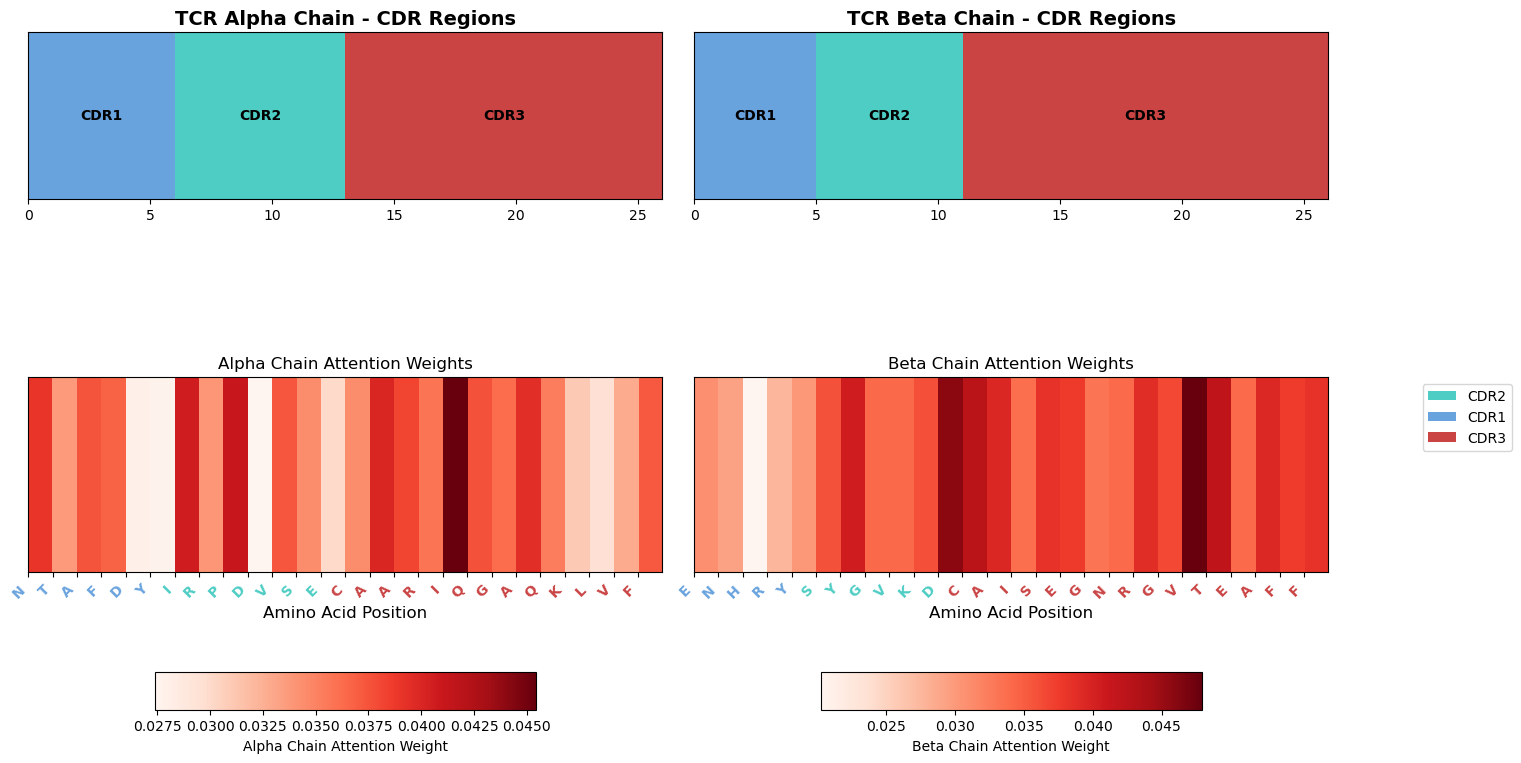

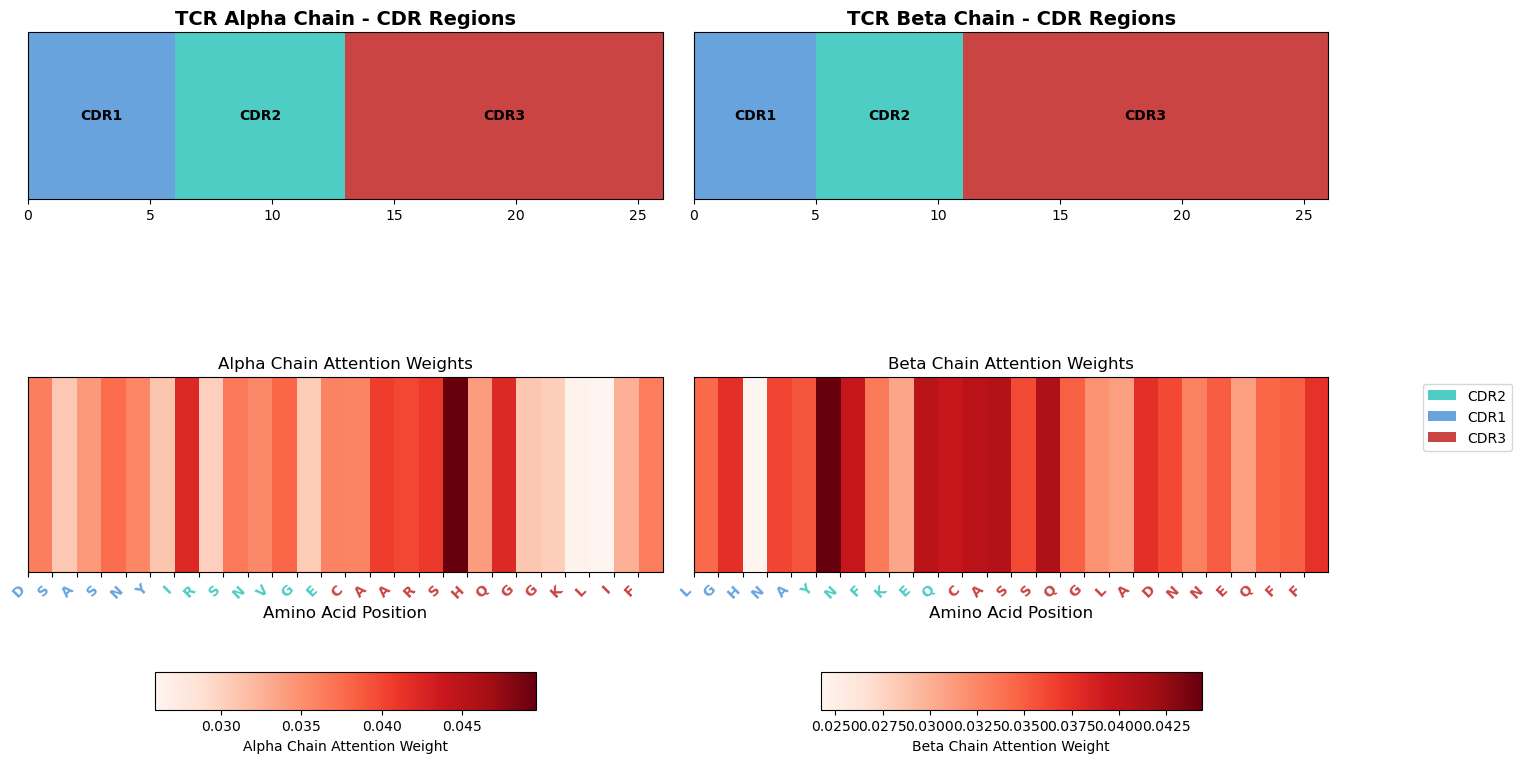

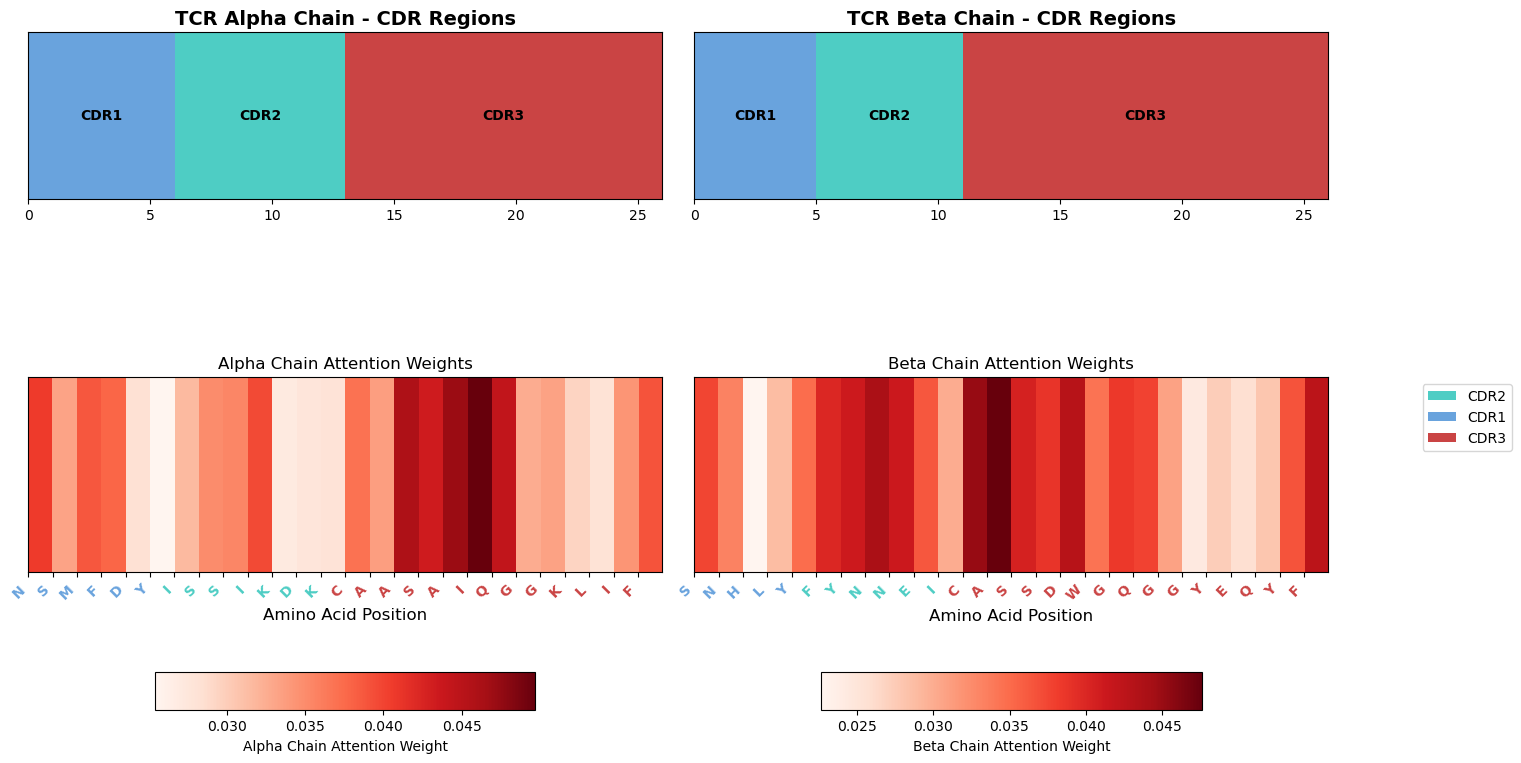

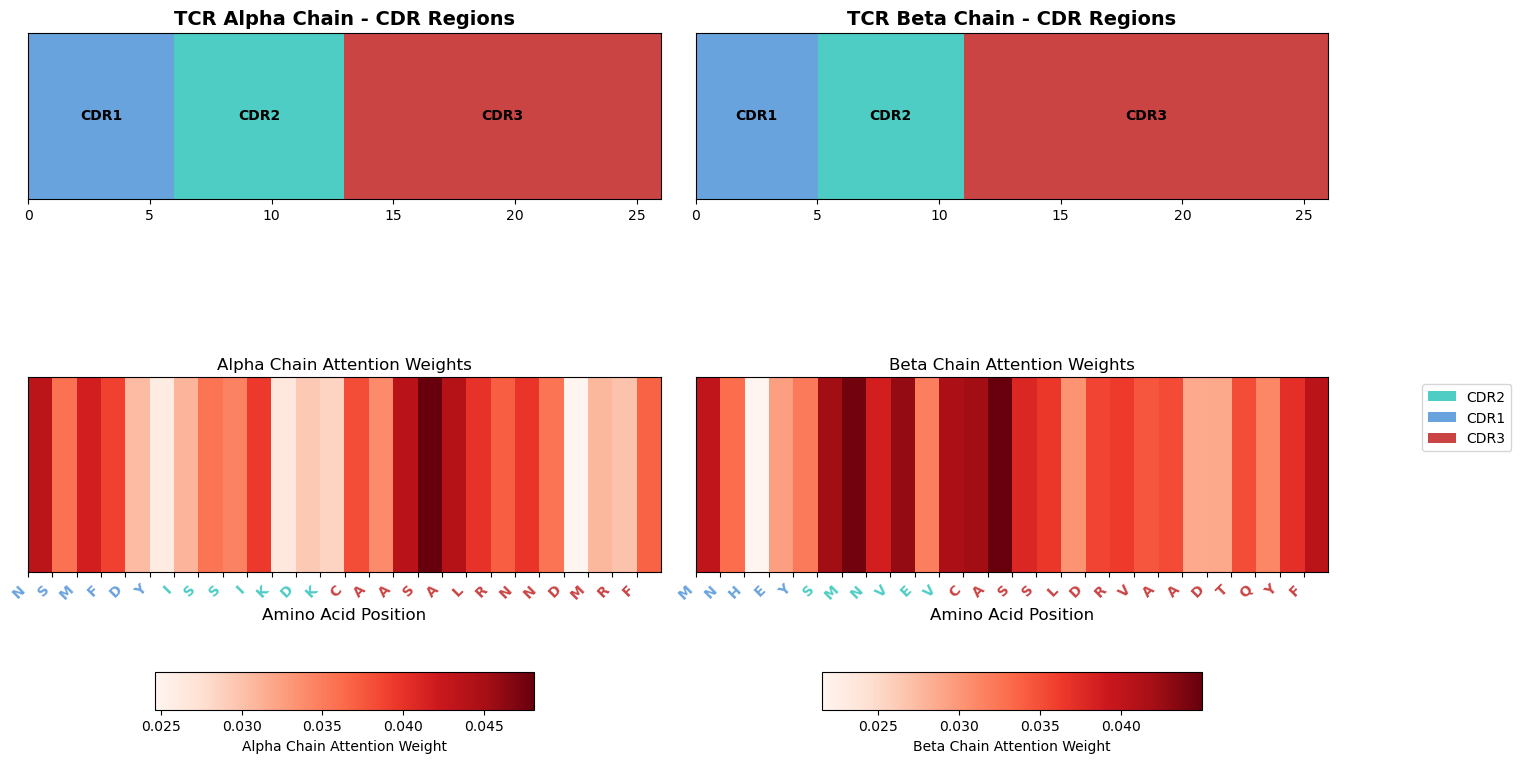

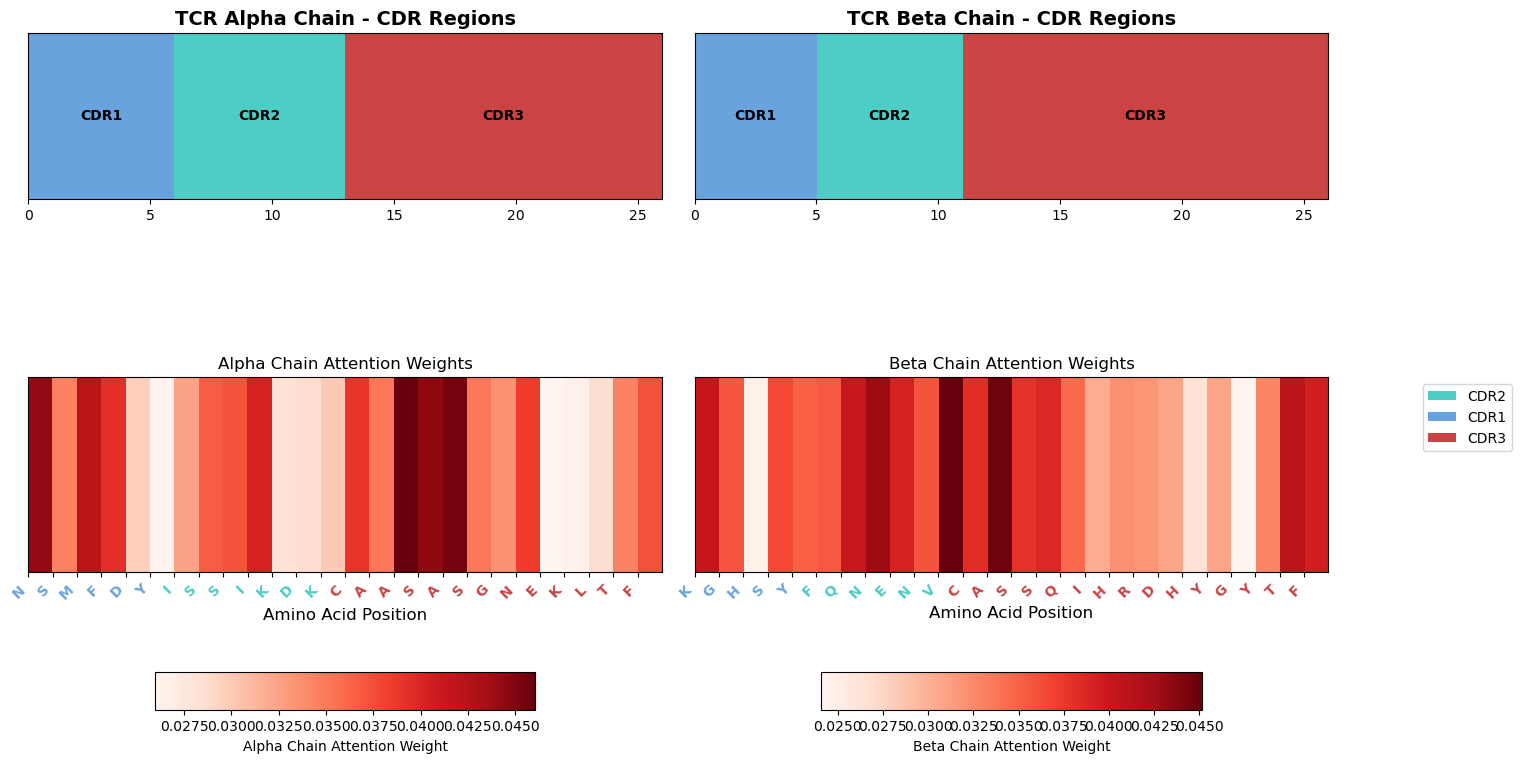

In [14]:
class_names = ['HLA-A*02:01', 'HLA-A*03:01'] #, 'HLA-A*11:01', 'HLA-B*08:01'
device = 'cpu' #torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TwoPartBertClassifier(pretrained='/mnt/d/TCRpair/bert',
                             n_output=2,
                             freeze_encoder=False,
                             separate_encoders=True,
                             seq_pooling="attention",
                             dropout=0.2)

# Load the trained weights
model.load_state_dict(torch.load("/mnt/d/TCRMI/results/log/attention/tcrhlastrict0203_attention2.pth", map_location=torch.device('cpu')))
#model = model.to(device)
model.eval()
# Load tokenizer
tokenizer = BertTokenizer.from_pretrained('/mnt/d/TCRpair/bert')
traindata = pd.read_csv("/mnt/d/TCRMI/datasets/hla_train3.csv")
traindata = traindata.drop_duplicates(subset=['full.alpha', 'full.beta'])
traindata['len_full_alpha'] = traindata['full.alpha'].astype(str).apply(len)
traindata['len_full_beta'] = traindata['full.beta'].astype(str).apply(len)
length_pairs = traindata.groupby(['len_full_alpha', 'len_full_beta']).size().reset_index(name='count')
most_popular = length_pairs.sort_values('count', ascending=False).iloc[0]

traindata = traindata[(traindata['len_full_alpha'] == most_popular['len_full_alpha']) & (traindata['len_full_beta'] == most_popular['len_full_beta'])]

for idx, hlatype in enumerate(class_names):
    filtered_df = traindata.loc[traindata['mhc.a'].str.contains(hlatype, na=False, regex=False)]
    filtered_df = complete_full_tcr(filtered_df)
    count = 0
    for i in np.arange(len(filtered_df)):
        tcr_alpha_sequence = filtered_df.iloc[i]['full.alpha']  # Your alpha chain sequence
        tcr_beta_sequence = filtered_df.iloc[i]['full.beta']       # Your beta chain sequence
        # Visualize attention
        results = extract_tcr_attention_from_model(
            model=model,
            tokenizer=tokenizer,
            tcr_alpha_sequence=tcr_alpha_sequence,
            tcr_beta_sequence=tcr_beta_sequence,
            device=device,
            class_names=class_names,
            max_len=40
        )
        if results['predicted_class'] == idx:
            plot_tcr_attention_both_chains(results, filtered_df.iloc[i],
                                           save_path=f"figures/HLA/attention_{hlatype}_{count}.pdf")
            count += 1
            if count == 5:
                break
    